# Section 1 — Title & Scope

## Member 4 — XGBoost & Advanced Hyperparameter Tuning

**Project:** Customer Churn Prediction & Business Intelligence System  
**Group:** Group 4 — Machine Learning  
**Branch:** `sanduni-ml-xgboost`  
**PR Target:** `group4-machine-learning`

### Member 4 Responsibilities
- Reuse the Group 3 feature-engineered dataset and core feature handoff
- Verify XGBoost version and use the current XGBClassifier API
- Build an initial/reference XGBoost classifier under the shared Group 4 protocol
- Evaluate with Accuracy, Precision, Recall, F1 and ROC-AUC using 5-fold stratified CV
- Perform a controlled hyperparameter search using training/CV data only
- Compare untuned vs tuned XGBoost under identical folds
- Analyze CV stability and generalization/overfitting
- Test `scale_pos_weight` as a secondary XGBoost-specific imbalance experiment
- Generate Member 4 output files, figures, probabilities, and candidate artifact

### Shared Group 4 Protocol (Do Not Change Alone)
| Item | Value |
|------|-------|
| Target | `Churn Value` |
| Train/Test split | 80% / 20%, stratified |
| Random state | 42 |
| Cross-validation | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` |
| Metrics | Accuracy, Precision, Recall, F1, ROC-AUC |
| Test set rule | **Used ONLY after final Group 4 model is locked — not for iterative tuning** |

### Leakage Blacklist
Never use: `Churn Label`, `Churn Score`, `Churn Reason` as predictors.

# Section 2 — Imports & Environment

In [1]:
# Standard library
import os
import warnings
import time

# Data handling
import numpy as np
import pandas as pd

# Machine learning
import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Model persistence
import joblib

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('=== Environment =========================')
print(f'xgboost   : {xgb.__version__}')
print(f'sklearn   : {__import__("sklearn").__version__}')
print(f'pandas    : {pd.__version__}')
print(f'numpy     : {np.__version__}')
print(f'matplotlib: {__import__("matplotlib").__version__}')
print(f'seaborn   : {sns.__version__}')
print(f'joblib    : {joblib.__version__}')
print('=========================================')

=== Environment =========================
xgboost   : 3.4.1
sklearn   : 1.9.0
pandas    : 3.0.3
numpy     : 2.4.6
matplotlib: 3.10.9
seaborn   : 0.13.2
joblib    : 1.5.3


# Section 3 — Load Data

In [2]:
# Repository-relative path: notebooks/ is two levels below the repo root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(
    REPO_ROOT,
    'Feature Engineering & Statistical Analysis',
    'outputs',
    'customer_churn_feature_engineered.csv'
)

OUT_DIR   = os.path.join(REPO_ROOT, 'Machine Learning', 'outputs')
FIG_DIR   = os.path.join(REPO_ROOT, 'Machine Learning', 'figures')
MODEL_DIR = os.path.join(REPO_ROOT, 'Machine Learning', 'models')

for d in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Data path : {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded — shape: {df.shape}')
df.head(3)

Data path : C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Feature Engineering & Statistical Analysis\outputs\customer_churn_feature_engineered.csv
Dataset loaded — shape: (7043, 29)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Churn Value,Is_New_Customer,Tenure_Band,Is_Month_to_Month,High_Monthly_Charge,Fiber_Monthly_Risk,New_High_Spend,New_Monthly_Customer,Support_Service_Count,Security_Tech_Bundle
0,Male,0,0,0,2,1,0,DSL,1,1,...,1,1,0-6,1,0,0,0,1,2,0
1,Female,0,0,1,2,1,0,Fiber optic,0,0,...,1,1,0-6,1,1,1,1,1,0,0
2,Female,0,0,1,8,1,1,Fiber optic,0,0,...,1,1,7-12,1,1,1,1,1,1,0


# Section 4 — Validate Handoff

In [3]:
print('=== Handoff Validation ================')
print(f'Rows   : {df.shape[0]:,}  (expected 7,043)')
print(f'Columns: {df.shape[1]}   (expected 29)')
assert df.shape == (7043, 29), 'Shape mismatch — check the dataset!'

assert 'Churn Value' in df.columns, 'Target column missing!'
n_non_churn = (df['Churn Value'] == 0).sum()
n_churn     = (df['Churn Value'] == 1).sum()
print(f'Non-churn: {n_non_churn} ({n_non_churn/len(df)*100:.2f}%)')
print(f'Churn    : {n_churn}  ({n_churn/len(df)*100:.2f}%)')
imbalance_ratio = n_non_churn / n_churn
print(f'Imbalance ratio (neg/pos): {imbalance_ratio:.3f}')

missing = df.isnull().sum()
print(f'Missing values total: {missing.sum()}')

LEAKAGE_COLS = ['Churn Label', 'Churn Score', 'Churn Reason', 'Total Frequency', 'CLTV']
present_leakage = [c for c in LEAKAGE_COLS if c in df.columns]
if present_leakage:
    print(f'Leakage columns present (will be excluded): {present_leakage}')
else:
    print('No leakage columns detected.')

CORE_FEATURES = [
    'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
    'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method',
    'Monthly Charges', 'Total Charges',
    'Fiber_Monthly_Risk', 'New_High_Spend', 'New_Monthly_Customer', 'Security_Tech_Bundle'
]
missing_core = [c for c in CORE_FEATURES if c not in df.columns]
if missing_core:
    raise ValueError(f'Missing core features: {missing_core}')
print(f'All 21 core features present.')
print('========================================')

=== Handoff Validation ================
Rows   : 7,043  (expected 7,043)
Columns: 29   (expected 29)
Non-churn: 5174 (73.46%)
Churn    : 1869  (26.54%)
Imbalance ratio (neg/pos): 2.768
Missing values total: 0
No leakage columns detected.
All 21 core features present.


# Section 5 — Preprocessing & Train/Test Split

In [4]:
TARGET = 'Churn Value'
X = df[CORE_FEATURES].copy()
y = df[TARGET].copy()

CAT_COLS = X.select_dtypes(include=['object', 'category']).columns.tolist()
NUM_COLS = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print(f'Categorical columns ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Numerical columns   ({len(NUM_COLS)}): {NUM_COLS}')

# XGBoost does NOT require numeric scaling.
# Categorical features are ordinal-encoded; encoding is fit on train only via Pipeline.
preprocessor = ColumnTransformer(
    transformers=[('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_COLS)],
    remainder='passthrough'
)

# Stratified 80/20 split — random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'\nTraining set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Train target distribution:')
print(y_train.value_counts())

Categorical columns (2): ['Internet Service', 'Contract']
Numerical columns   (19): ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Fiber_Monthly_Risk', 'New_High_Spend', 'New_Monthly_Customer', 'Security_Tech_Bundle']

Training set : 5,634 rows
Test set     : 1,409 rows
Train target distribution:
Churn Value
0    4139
1    1495
Name: count, dtype: int64


In [5]:
# Common CV protocol — must match all members
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
}

def summarise_cv(cv_results, model_name='Model'):
    rows = []
    for metric_key in SCORING:
        test_scores  = cv_results.get(f'test_{metric_key}',  np.array([np.nan]))
        train_scores = cv_results.get(f'train_{metric_key}', np.array([np.nan]))
        rows.append({
            'model_name' : model_name,
            'metric'     : metric_key,
            'cv_mean'    : round(test_scores.mean(), 4),
            'cv_std'     : round(test_scores.std(),  4),
            'train_mean' : round(train_scores.mean(), 4),
            'train_std'  : round(train_scores.std(),  4),
            'fold_scores': list(np.round(test_scores, 4)),
        })
    return pd.DataFrame(rows)

print('CV protocol: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)')

CV protocol: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Section 6 — Initial / Reference XGBoost

In [6]:
# Reference XGBoost — sensible defaults before any tuning
xgb_initial = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 4,
        random_state  = RANDOM_STATE,
        eval_metric   = 'logloss',
        tree_method   = 'hist',
    ))
])

print('Initial XGBClassifier:')
print(xgb_initial.named_steps['classifier'].get_params())

Initial XGBClassifier:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


# Section 7 — Common CV Evaluation (Initial Model)

In [7]:
print('Running 5-fold CV on initial XGBoost ...')
t0 = time.time()

cv_initial = cross_validate(
    xgb_initial, X_train, y_train,
    cv=CV, scoring=SCORING, return_train_score=True, n_jobs=-1
)
print(f'Done in {time.time()-t0:.1f}s')

df_cv_initial = summarise_cv(cv_initial, model_name='XGBoost_Initial')

print('\n=== Initial XGBoost — CV Results ===')
print(df_cv_initial[['metric', 'cv_mean', 'cv_std', 'train_mean']].to_string(index=False))

# Save
cv_path = os.path.join(OUT_DIR, 'member4_xgboost_cv_results.csv')
df_cv_initial.to_csv(cv_path, index=False)
print(f'\nSaved: {cv_path}')

Running 5-fold CV on initial XGBoost ...


Done in 2.6s

=== Initial XGBoost — CV Results ===
   metric  cv_mean  cv_std  train_mean
 accuracy   0.8072  0.0090      0.8407
precision   0.6648  0.0260      0.7356
   recall   0.5538  0.0201      0.6242
       f1   0.6039  0.0170      0.6753
  roc_auc   0.8582  0.0094      0.9065

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\member4_xgboost_cv_results.csv


# Section 8 — Hyperparameter Search

In [8]:
# Search space — highest-impact parameters first
PARAM_DIST = {
    'classifier__n_estimators'    : [100, 200, 300, 500],
    'classifier__learning_rate'   : [0.03, 0.05, 0.10, 0.20],
    'classifier__max_depth'       : [2, 3, 4, 5, 6],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__subsample'       : [0.70, 0.85, 1.00],
    'classifier__colsample_bytree': [0.70, 0.85, 1.00],
    'classifier__gamma'           : [0, 0.1, 0.3],
    'classifier__reg_alpha'       : [0, 0.01, 0.1, 0.5],
    'classifier__reg_lambda'      : [1, 1.5, 2.0],
}

xgb_tuning_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss', tree_method='hist'
    ))
])

# RandomizedSearchCV on TRAINING DATA ONLY — test set never touched here
random_search = RandomizedSearchCV(
    estimator=xgb_tuning_base,
    param_distributions=PARAM_DIST,
    n_iter=40,
    scoring='f1',
    cv=CV,
    refit=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print('Running RandomizedSearchCV (n_iter=40, cv=5, scoring=f1) ...')
t0 = time.time()
random_search.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')

print(f'\nBest CV F1 score : {random_search.best_score_:.4f}')
print('Best parameters  :')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')

Running RandomizedSearchCV (n_iter=40, cv=5, scoring=f1) ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


Done in 8.0s

Best CV F1 score : 0.6161
Best parameters  :
  classifier__subsample: 0.85
  classifier__reg_lambda: 1.5
  classifier__reg_alpha: 0.01
  classifier__n_estimators: 200
  classifier__min_child_weight: 3
  classifier__max_depth: 3
  classifier__learning_rate: 0.03
  classifier__gamma: 0
  classifier__colsample_bytree: 0.7


In [9]:
# Save tuning results
df_tuning = pd.DataFrame(random_search.cv_results_)
keep_cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_fit_time']
param_cols = [c for c in df_tuning.columns if c.startswith('param_')]
df_tuning_out = df_tuning[keep_cols + param_cols].sort_values('rank_test_score')

tuning_path = os.path.join(OUT_DIR, 'member4_xgboost_tuning_results.csv')
df_tuning_out.to_csv(tuning_path, index=False)
print(f'Saved: {tuning_path}')
print('\nTop 5 configurations:')
print(df_tuning_out.head(5).to_string(index=False))

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\member4_xgboost_tuning_results.csv

Top 5 configurations:
 rank_test_score  mean_test_score  std_test_score  mean_fit_time  param_classifier__subsample  param_classifier__reg_lambda  param_classifier__reg_alpha  param_classifier__n_estimators  param_classifier__min_child_weight  param_classifier__max_depth  param_classifier__learning_rate  param_classifier__gamma  param_classifier__colsample_bytree
               1         0.616066        0.024851       0.249978                         0.85                           1.5                         0.01                             200                                   3                            3                             0.03                      0.0                                0.70
               2         0.610069        0.016639       0.504407                         0.85                           1.0         

# Section 9 — Tuned Candidate — Full CV Evaluation

In [10]:
best_params = dict(random_search.best_params_)

xgb_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        **{k.replace('classifier__', ''): v for k, v in best_params.items()},
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        tree_method='hist',
    ))
])

print('Running full 5-metric CV on tuned XGBoost ...')
t0 = time.time()
cv_tuned = cross_validate(
    xgb_tuned, X_train, y_train,
    cv=CV, scoring=SCORING, return_train_score=True, n_jobs=-1
)
print(f'Done in {time.time()-t0:.1f}s')

df_cv_tuned = summarise_cv(cv_tuned, model_name='XGBoost_Tuned')

print('\n=== Tuned XGBoost — CV Results ===')
print(df_cv_tuned[['metric', 'cv_mean', 'cv_std', 'train_mean']].to_string(index=False))

Running full 5-metric CV on tuned XGBoost ...


Done in 0.3s

=== Tuned XGBoost — CV Results ===
   metric  cv_mean  cv_std  train_mean
 accuracy   0.8117  0.0133      0.8241
precision   0.6720  0.0337      0.7008
   recall   0.5692  0.0246      0.5883
       f1   0.6161  0.0249      0.6396
  roc_auc   0.8631  0.0105      0.8799


# Section 10 — Generalization Analysis

In [11]:
df_gen = pd.concat([df_cv_initial, df_cv_tuned], ignore_index=True)
df_gen['train_cv_gap'] = (df_gen['train_mean'] - df_gen['cv_mean']).round(4)

print('=== Generalization Analysis: Initial vs Tuned ===')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    ri = df_gen[(df_gen['model_name']=='XGBoost_Initial') & (df_gen['metric']==metric)].iloc[0]
    rt = df_gen[(df_gen['model_name']=='XGBoost_Tuned')   & (df_gen['metric']==metric)].iloc[0]
    d  = rt['cv_mean'] - ri['cv_mean']
    print(f'{metric:<12} | '
          f'Initial CV:{ri["cv_mean"]:.4f}+-{ri["cv_std"]:.4f} gap:{ri["train_cv_gap"]:+.4f} | '
          f'Tuned CV:{rt["cv_mean"]:.4f}+-{rt["cv_std"]:.4f} gap:{rt["train_cv_gap"]:+.4f} | '
          f'Delta:{d:+.4f}')

print('\nNote: train_cv_gap > 0.05 suggests potential overfitting.')
print('Large cv_std suggests fold instability.')

=== Generalization Analysis: Initial vs Tuned ===
accuracy     | Initial CV:0.8072+-0.0090 gap:+0.0335 | Tuned CV:0.8117+-0.0133 gap:+0.0124 | Delta:+0.0045
precision    | Initial CV:0.6648+-0.0260 gap:+0.0708 | Tuned CV:0.6720+-0.0337 gap:+0.0288 | Delta:+0.0072
recall       | Initial CV:0.5538+-0.0201 gap:+0.0704 | Tuned CV:0.5692+-0.0246 gap:+0.0191 | Delta:+0.0154
f1           | Initial CV:0.6039+-0.0170 gap:+0.0714 | Tuned CV:0.6161+-0.0249 gap:+0.0235 | Delta:+0.0122
roc_auc      | Initial CV:0.8582+-0.0094 gap:+0.0483 | Tuned CV:0.8631+-0.0105 gap:+0.0168 | Delta:+0.0049

Note: train_cv_gap > 0.05 suggests potential overfitting.
Large cv_std suggests fold instability.


In [12]:
# Save generalization results
df_gen['parameter_strategy'] = df_gen['model_name'].map({
    'XGBoost_Initial': 'reference_defaults',
    'XGBoost_Tuned'  : 'RandomizedSearchCV_n40'
})
df_gen['best_params'] = df_gen['model_name'].map({
    'XGBoost_Initial': 'n_estimators=100, learning_rate=0.1, max_depth=4',
    'XGBoost_Tuned'  : str(best_params)
})

gen_path = os.path.join(OUT_DIR, 'member4_xgboost_generalization_results.csv')
df_gen.to_csv(gen_path, index=False)
print(f'Saved: {gen_path}')

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\member4_xgboost_generalization_results.csv


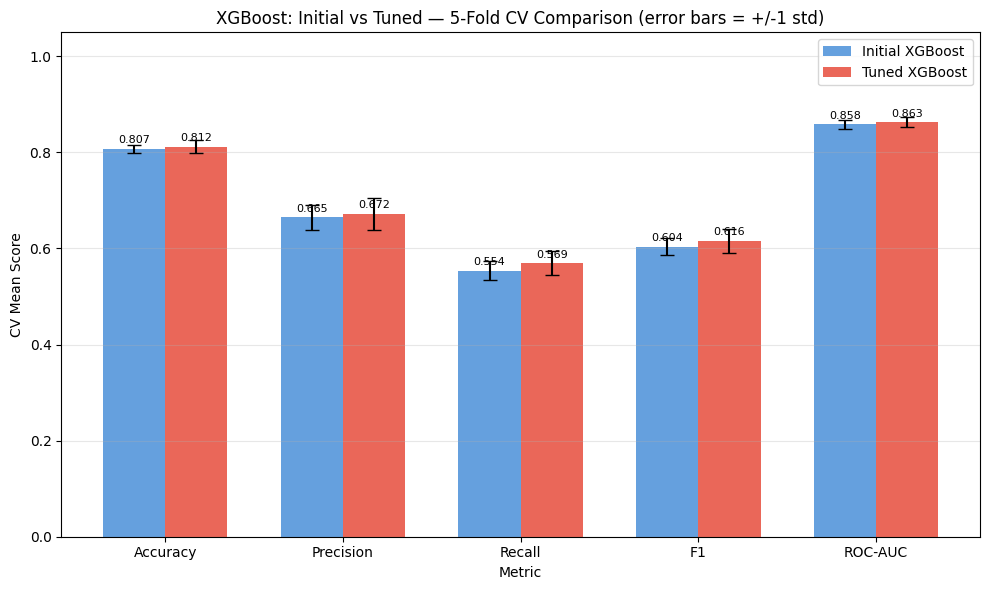

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\figures\member4_xgboost_tuning_comparison.png


In [13]:
# Tuning comparison bar chart
metrics_order = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
labels        = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

get_m = lambda df_s, m: df_s[df_s['metric']==m]['cv_mean'].values[0]
get_s = lambda df_s, m: df_s[df_s['metric']==m]['cv_std'].values[0]

init_means  = [get_m(df_cv_initial, m) for m in metrics_order]
tuned_means = [get_m(df_cv_tuned,   m) for m in metrics_order]
init_stds   = [get_s(df_cv_initial, m) for m in metrics_order]
tuned_stds  = [get_s(df_cv_tuned,   m) for m in metrics_order]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - w/2, init_means,  w, yerr=init_stds,  label='Initial XGBoost', color='#4A90D9', alpha=0.85, capsize=5)
b2 = ax.bar(x + w/2, tuned_means, w, yerr=tuned_stds, label='Tuned XGBoost',   color='#E74C3C', alpha=0.85, capsize=5)
ax.set_xlabel('Metric'); ax.set_ylabel('CV Mean Score')
ax.set_title('XGBoost: Initial vs Tuned — 5-Fold CV Comparison (error bars = +/-1 std)', fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in [*b1, *b2]:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
tuning_cmp_path = os.path.join(FIG_DIR, 'member4_xgboost_tuning_comparison.png')
plt.savefig(tuning_cmp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {tuning_cmp_path}')

# Section 11 — scale_pos_weight Experiment (XGBoost-Specific Imbalance)

In [14]:
# scale_pos_weight = n_non_churn / n_churn (approx. 2.77)
# This is XGBoost-specific and SEPARATE from Member 3 SMOTE/class-weight work.
scale_pos_weight_val = round(n_non_churn / n_churn, 3)
print(f'scale_pos_weight = {scale_pos_weight_val}')

best_clf_params = {k.replace('classifier__', ''): v for k, v in best_params.items()}

xgb_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        **best_clf_params,
        scale_pos_weight=scale_pos_weight_val,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        tree_method='hist',
    ))
])

print('Running CV on weighted XGBoost ...')
t0 = time.time()
cv_weighted = cross_validate(
    xgb_weighted, X_train, y_train,
    cv=CV, scoring=SCORING, return_train_score=True, n_jobs=-1
)
print(f'Done in {time.time()-t0:.1f}s')

df_cv_weighted = summarise_cv(cv_weighted, model_name='XGBoost_Weighted')
print('\n=== XGBoost with scale_pos_weight — CV Results ===')
print(df_cv_weighted[['metric', 'cv_mean', 'cv_std']].to_string(index=False))

scale_pos_weight = 2.768
Running CV on weighted XGBoost ...


Done in 0.2s

=== XGBoost with scale_pos_weight — CV Results ===
   metric  cv_mean  cv_std
 accuracy   0.7583  0.0142
precision   0.5291  0.0186
   recall   0.8174  0.0303
       f1   0.6422  0.0194
  roc_auc   0.8629  0.0104


In [15]:
# Business trade-off comparison
print('\n=== Business Trade-off: Precision vs Recall vs F1 ===')
print(f'{"Model":<22} {"Precision":>10} {"Recall":>10} {"F1":>10} {"ROC-AUC":>10}')
print('-' * 65)

for mname, df_s in [
    ('XGBoost_Initial',  df_cv_initial),
    ('XGBoost_Tuned',    df_cv_tuned),
    ('XGBoost_Weighted', df_cv_weighted),
]:
    g = lambda m: df_s[df_s['metric']==m]['cv_mean'].values[0]
    print(f'{mname:<22} {g("precision"):>10.4f} {g("recall"):>10.4f} {g("f1"):>10.4f} {g("roc_auc"):>10.4f}')

print('\nHigher recall = more true churners caught.')
print('Higher precision = fewer non-churners falsely flagged.')


=== Business Trade-off: Precision vs Recall vs F1 ===
Model                   Precision     Recall         F1    ROC-AUC
-----------------------------------------------------------------
XGBoost_Initial            0.6648     0.5538     0.6039     0.8582
XGBoost_Tuned              0.6720     0.5692     0.6161     0.8631
XGBoost_Weighted           0.5291     0.8174     0.6422     0.8629

Higher recall = more true churners caught.
Higher precision = fewer non-churners falsely flagged.


# Section 12 — Confusion Matrix, ROC Curve, Probabilities

In [16]:
# Select the candidate model based on CV F1 (and Recall as tiebreaker)
f1_t = df_cv_tuned   [df_cv_tuned   ['metric']=='f1']['cv_mean'].values[0]
f1_w = df_cv_weighted[df_cv_weighted['metric']=='f1']['cv_mean'].values[0]
re_t = df_cv_tuned   [df_cv_tuned   ['metric']=='recall']['cv_mean'].values[0]
re_w = df_cv_weighted[df_cv_weighted['metric']=='recall']['cv_mean'].values[0]

print(f'Tuned    F1={f1_t:.4f}  Recall={re_t:.4f}')
print(f'Weighted F1={f1_w:.4f}  Recall={re_w:.4f}')

if f1_t >= f1_w - 0.002 and re_t >= re_w:
    CANDIDATE_NAME     = 'XGBoost_Tuned'
    CANDIDATE_PIPELINE = xgb_tuned
    CANDIDATE_CV_DF    = df_cv_tuned
else:
    CANDIDATE_NAME     = 'XGBoost_Weighted'
    CANDIDATE_PIPELINE = xgb_weighted
    CANDIDATE_CV_DF    = df_cv_weighted

print(f'\nSelected candidate: {CANDIDATE_NAME}')
print('Fitting on full training set ...')
CANDIDATE_PIPELINE.fit(X_train, y_train)
print('Done.')

Tuned    F1=0.6161  Recall=0.5692
Weighted F1=0.6422  Recall=0.8174

Selected candidate: XGBoost_Weighted
Fitting on full training set ...
Done.


In [17]:
# Held-out test evaluation — ONCE only, after candidate is locked
y_pred = CANDIDATE_PIPELINE.predict(X_test)
y_prob = CANDIDATE_PIPELINE.predict_proba(X_test)[:, 1]

test_acc  = accuracy_score (y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec  = recall_score   (y_test, y_pred)
test_f1   = f1_score       (y_test, y_pred)
test_auc  = roc_auc_score  (y_test, y_prob)

print(f'=== {CANDIDATE_NAME} — Held-Out Test Set ===')
print(f'  Accuracy : {test_acc:.4f}')
print(f'  Precision: {test_prec:.4f}')
print(f'  Recall   : {test_rec:.4f}')
print(f'  F1-score : {test_f1:.4f}')
print(f'  ROC-AUC  : {test_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

=== XGBoost_Weighted — Held-Out Test Set ===
  Accuracy : 0.7523
  Precision: 0.5215
  Recall   : 0.8102
  F1-score : 0.6346
  ROC-AUC  : 0.8527

              precision    recall  f1-score   support

   Non-Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



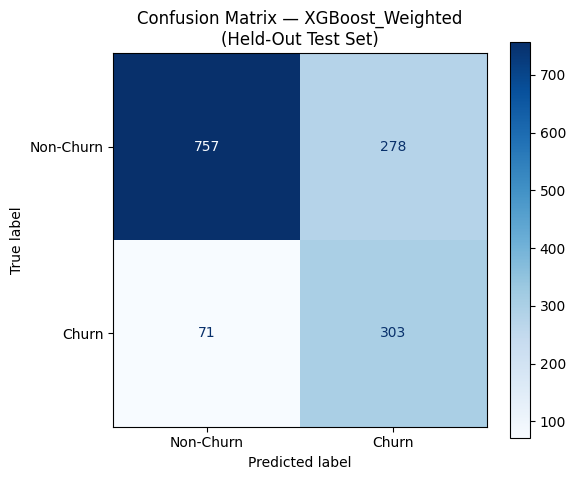

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\figures\member4_xgboost_confusion_matrix.png
TP (churners correctly caught)   : 303
FN (churners missed)             : 71  <- lost retention opportunity
FP (non-churners falsely flagged): 278  <- wasted retention spend
TN                               : 757


In [18]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Churn','Churn']).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {CANDIDATE_NAME}\n(Held-Out Test Set)')
plt.tight_layout()
cm_path = os.path.join(FIG_DIR, 'member4_xgboost_confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

tn, fp, fn, tp = cm.ravel()
print(f'TP (churners correctly caught)   : {tp}')
print(f'FN (churners missed)             : {fn}  <- lost retention opportunity')
print(f'FP (non-churners falsely flagged): {fp}  <- wasted retention spend')
print(f'TN                               : {tn}')

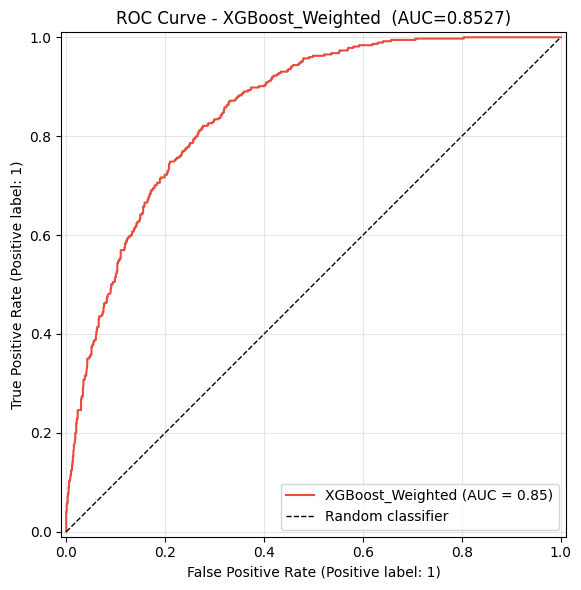

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\figures\member4_xgboost_roc_curve.png


In [19]:
# ROC Curve
# sklearn 1.9+ removed color kwarg from from_predictions();
# set line color via the returned display object instead.
fig, ax = plt.subplots(figsize=(7, 6))
roc_disp = RocCurveDisplay.from_predictions(y_test, y_prob, name=CANDIDATE_NAME, ax=ax)
roc_disp.line_.set_color('#E74C3C')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random classifier')
ax.set_title(f'ROC Curve - {CANDIDATE_NAME}  (AUC={test_auc:.4f})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(FIG_DIR, 'member4_xgboost_roc_curve.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {roc_path}')

In [20]:
# Churn probability output — positive class only, no thresholds invented here
df_proba = X_test.reset_index(drop=False).rename(columns={'index':'original_row_index'})
df_proba['churn_probability'] = y_prob
df_proba['true_churn']        = y_test.values
prob_path = os.path.join(OUT_DIR, 'member4_xgboost_probabilities.csv')
df_proba[['original_row_index','churn_probability','true_churn']].to_csv(prob_path, index=False)
print(f'Saved: {prob_path}')
print(f'Probability range: {y_prob.min():.4f} - {y_prob.max():.4f}')

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\member4_xgboost_probabilities.csv
Probability range: 0.0081 - 0.9426


# Section 13 — Feature Importance (Optional Supporting Analysis)

In [21]:
# Feature importance — gain method
# CAUTION: reflects model behaviour, NOT causal business proof.
xgb_clf = CANDIDATE_PIPELINE.named_steps['classifier']
prep    = CANDIDATE_PIPELINE.named_steps['preprocessor']

try:
    cat_names = prep.named_transformers_['ord'].get_feature_names_out(CAT_COLS).tolist()
except Exception:
    cat_names = CAT_COLS

feature_names_out = cat_names + NUM_COLS
importances = xgb_clf.feature_importances_

if len(importances) != len(feature_names_out):
    feature_names_out = CORE_FEATURES[:len(importances)]

df_importance = pd.DataFrame({
    'feature'   : feature_names_out[:len(importances)],
    'importance': importances
}).sort_values('importance', ascending=False)

fi_path = os.path.join(OUT_DIR, 'member4_xgboost_feature_importance.csv')
df_importance.to_csv(fi_path, index=False)
print(f'Saved: {fi_path}')
print('\nTop 10 features by gain importance:')
print(df_importance.head(10).to_string(index=False))

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\member4_xgboost_feature_importance.csv

Top 10 features by gain importance:


             feature  importance
  Fiber_Monthly_Risk    0.286017
            Contract    0.191209
New_Monthly_Customer    0.111860
      New_High_Spend    0.063554
          Dependents    0.056720
    Internet Service    0.038562
    Streaming Movies    0.029185
       Tenure Months    0.028900
   Paperless Billing    0.027760
     Online Security    0.025381


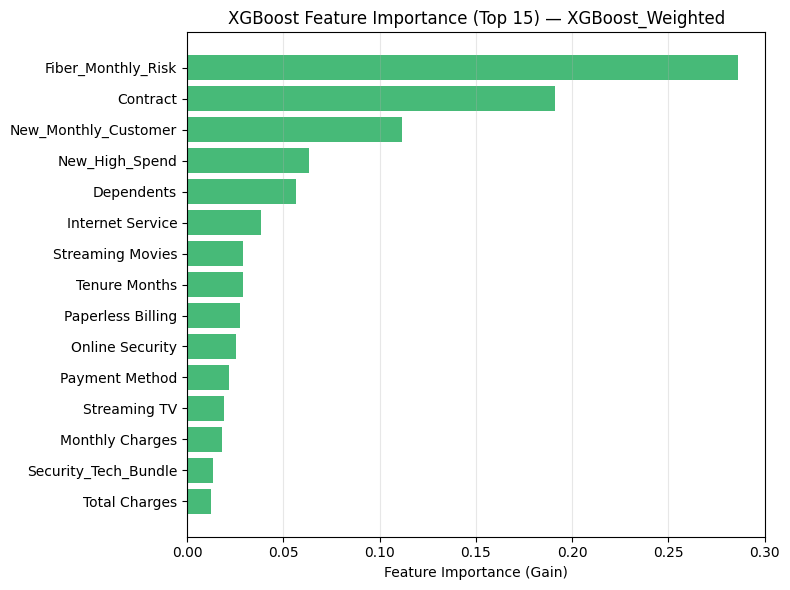

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\figures\member4_xgboost_feature_importance.png


In [22]:
top_n = min(15, len(df_importance))
df_top = df_importance.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_top['feature'][::-1], df_top['importance'][::-1], color='#27AE60', alpha=0.85)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title(f'XGBoost Feature Importance (Top {top_n}) — {CANDIDATE_NAME}')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fi_fig_path = os.path.join(FIG_DIR, 'member4_xgboost_feature_importance.png')
plt.savefig(fi_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fi_fig_path}')

# Section 14 — Save Candidate Model Artifact

In [23]:
model_artifact_path = os.path.join(MODEL_DIR, 'member4_xgboost_candidate.joblib')
joblib.dump(CANDIDATE_PIPELINE, model_artifact_path)
print(f'Saved: {model_artifact_path}')

# Reload verification
reloaded = joblib.load(model_artifact_path)
assert np.array_equal(y_pred, reloaded.predict(X_test)), 'Reload check failed!'
print('Reload verified — predictions match.')

# Build integration-ready summary CSV
def get_metric(df_cv, metric):
    row = df_cv[df_cv['metric']==metric].iloc[0]
    return row['cv_mean'], row['cv_std']

summary_rows = []
for stage, df_cv_s in [
    ('Initial',  df_cv_initial),
    ('Tuned',    df_cv_tuned),
    ('Weighted', df_cv_weighted),
]:
    row = {'model_name': f'XGBoost_{stage}', 'stage': stage, 'parameter_strategy': 'RandomizedSearchCV_n40' if stage!='Initial' else 'reference_defaults'}
    for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        mean, std = get_metric(df_cv_s, m)
        row[f'{m}_mean'] = mean
        row[f'{m}_std']  = std
    summary_rows.append(row)

summary_rows.append({
    'model_name': CANDIDATE_NAME+'_TEST', 'stage': 'test_held_out',
    'parameter_strategy': 'final_test_evaluation',
    'accuracy_mean': round(test_acc,4), 'precision_mean': round(test_prec,4),
    'recall_mean': round(test_rec,4), 'f1_mean': round(test_f1,4),
    'roc_auc_mean': round(test_auc,4),
})

df_summary = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUT_DIR, 'member4_xgboost_summary.csv')
df_summary.to_csv(summary_path, index=False)
print(f'Saved summary: {summary_path}')
df_summary

Saved: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\models\member4_xgboost_candidate.joblib
Reload verified — predictions match.
Saved summary: C:\Users\victus\Desktop\Repository\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\member4_xgboost_summary.csv


,model_name,stage,parameter_strategy,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,XGBoost_Initial,Initial,reference_defaults,0.8072,0.0090,0.6648,0.0260,0.5538,0.0201,0.6039,0.0170,0.8582,0.0094
1,XGBoost_Tuned,Tuned,RandomizedSearchCV_n40,0.8117,0.0133,0.6720,0.0337,0.5692,0.0246,0.6161,0.0249,0.8631,0.0105
2,XGBoost_Weighted,Weighted,RandomizedSearchCV_n40,0.7583,0.0142,0.5291,0.0186,0.8174,0.0303,0.6422,0.0194,0.8629,0.0104
3,XGBoost_Weighted_TEST,test_held_out,final_test_evaluation,0.7523,NaN,0.5215,NaN,0.8102,NaN,0.6346,NaN,0.8527,NaN


# Section 15 — Summary & Recommendation

In [24]:
print('=' * 60)
print('  MEMBER 4 — XGBoost FINAL SUMMARY')
print('=' * 60)
print(f'\nCandidate: {CANDIDATE_NAME}')
print(f'Best params: {best_params}')

print('\n--- CV Metrics (5-Fold Stratified, Training Data) ---')
for m in ['accuracy','precision','recall','f1','roc_auc']:
    mean, std = get_metric(CANDIDATE_CV_DF, m)
    print(f'  {m:<12}: {mean:.4f} +/- {std:.4f}')

print('\n--- Held-Out Test Metrics (Single Evaluation) ---')
print(f'  Accuracy : {test_acc:.4f}')
print(f'  Precision: {test_prec:.4f}')
print(f'  Recall   : {test_rec:.4f}')
print(f'  F1-score : {test_f1:.4f}')
print(f'  ROC-AUC  : {test_auc:.4f}')

print('\n--- Strengths ---')
print('  Handles non-linear interactions in tabular churn data.')
print('  Controlled RandomizedSearchCV (n_iter=40) keeps search reproducible.')
print('  predict_proba() provides ranked churn probabilities for downstream use.')
print('  Regularisation (gamma, reg_alpha, reg_lambda) reduces overfitting risk.')

print('\n--- Cautions ---')
print('  Feature importance = model behaviour, NOT causal proof.')
print('  scale_pos_weight trades Precision for Recall — review with Member 3.')

print('\n--- Business Trade-Off ---')
print('  FN (missed churner) = lost retention opportunity.')
print('  FP (false churn flag) = wasted retention spend.')
print('  Threshold rules should be agreed by the full team.')

print('\n--- IMPORTANT: Do NOT declare XGBoost the final model. ---')
print('  All four branches must merge into group4-machine-learning first.')
print('  Final model is a shared Group 4 decision.')
print('=' * 60)

# Output checklist
print('\n=== Output File Checklist ===')
files_to_check = [
    (OUT_DIR,   'member4_xgboost_cv_results.csv'),
    (OUT_DIR,   'member4_xgboost_tuning_results.csv'),
    (OUT_DIR,   'member4_xgboost_generalization_results.csv'),
    (OUT_DIR,   'member4_xgboost_probabilities.csv'),
    (OUT_DIR,   'member4_xgboost_feature_importance.csv'),
    (OUT_DIR,   'member4_xgboost_summary.csv'),
    (FIG_DIR,   'member4_xgboost_confusion_matrix.png'),
    (FIG_DIR,   'member4_xgboost_roc_curve.png'),
    (FIG_DIR,   'member4_xgboost_tuning_comparison.png'),
    (FIG_DIR,   'member4_xgboost_feature_importance.png'),
    (MODEL_DIR, 'member4_xgboost_candidate.joblib'),
]
for d, f in files_to_check:
    exists = os.path.isfile(os.path.join(d, f))
    print(f'  {"OK" if exists else "MISSING"} {f}')

print('\nPR target: sanduni-ml-xgboost -> group4-machine-learning')

  MEMBER 4 — XGBoost FINAL SUMMARY

Candidate: XGBoost_Weighted
Best params: {'classifier__subsample': 0.85, 'classifier__reg_lambda': 1.5, 'classifier__reg_alpha': 0.01, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 3, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.03, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.7}

--- CV Metrics (5-Fold Stratified, Training Data) ---
  accuracy    : 0.7583 +/- 0.0142
  precision   : 0.5291 +/- 0.0186
  recall      : 0.8174 +/- 0.0303
  f1          : 0.6422 +/- 0.0194
  roc_auc     : 0.8629 +/- 0.0104

--- Held-Out Test Metrics (Single Evaluation) ---
  Accuracy : 0.7523
  Precision: 0.5215
  Recall   : 0.8102
  F1-score : 0.6346
  ROC-AUC  : 0.8527

--- Strengths ---
  Handles non-linear interactions in tabular churn data.
  Controlled RandomizedSearchCV (n_iter=40) keeps search reproducible.
  predict_proba() provides ranked churn probabilities for downstream use.
  Regularisation (gamma, reg_alpha, reg_